# Temporal backtesting before architecture tuning

This studybook explains how to compare temporal models without repeatedly consulting the final 2018 holdout. It assumes notebook `05`'s label-availability clock and notebook `06`'s causal temporal messages, but no knowledge of financial backtesting. We will construct expanding windows, inspect label support, compare three model families through time, and decide where a Transformer is—and is not—a sensible next experiment.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from graph_ml.evaluation import (
    ExpandingWindowPlan,
    build_expanding_window_specs,
    build_horizon_label_availability,
    build_point_in_time_fold,
)
from graph_ml.viz import (
    plot_backtest_pr_auc,
    plot_expanding_backtest_windows,
    plot_temporal_attention_schematic,
)

ROOT = next(path for path in (Path.cwd(), *Path.cwd().parents) if (path / 'pyproject.toml').exists())
DATA = ROOT / 'data'

## 1. Why one test period is not enough

Once a result has been read, that period is no longer pristine for making design choices. Repeatedly changing decay, gates, or architecture after seeing the April–December 2018 score would turn the test set into an informal validation set.

A **rolling-origin backtest** creates earlier miniature deployments. Training always uses the past, validation selects epochs or tree count, and the following period measures the frozen choice. The training history expands in the next fold. The final holdout stays visually and computationally separate.

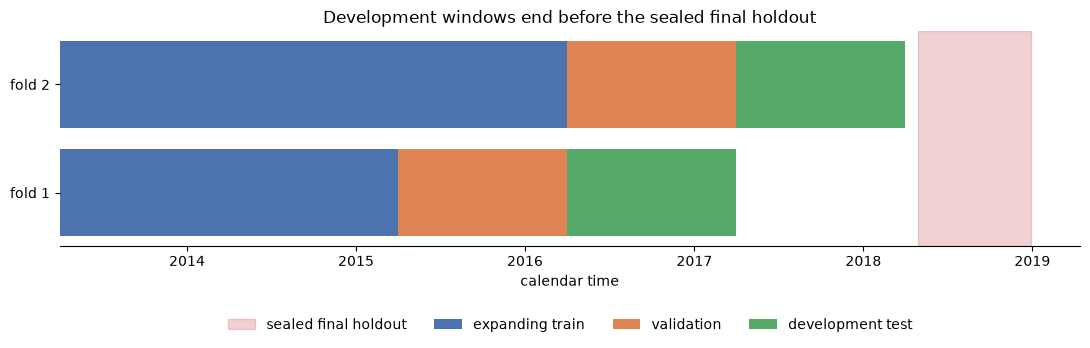

In [2]:
plan = ExpandingWindowPlan(
    first_train_end='2015-04-01',
    window_months=12,
    fold_count=2,
    final_holdout_start='2018-04-30',
)
specs = build_expanding_window_specs(plan)
plot_expanding_backtest_windows(specs, final_holdout_start=plan.final_holdout_start)
plt.show()

The blue training region grows. Orange validation and green development-test regions remain chronological and disjoint. Red is not used to choose architecture. Notice that the first fold can train on events earlier than the displayed blue start; the chart truncates old history so the decision windows remain legible.

## 2. Calendar length is not statistical support

A p90 outcome is conservatively known at `due_date + 90 days`. Therefore the end of a window censors its latest invoices. Four-month calendar windows looked reasonable but produced **zero** mature positives in some validation cohorts; an initial eight-month proposal left one validation block with only nine. The runner now rejects any train, validation, or test partition with fewer than ten examples of either class. Twelve-month windows pass that minimum.

,fold,partition,rows,positives,prevalence
0,1,train,547,19,3.47%
1,1,validation,634,72,11.36%
2,1,development test,6604,27,0.41%
3,2,train,1388,107,7.71%
4,2,validation,6604,27,0.41%
5,2,development test,21556,2106,9.77%


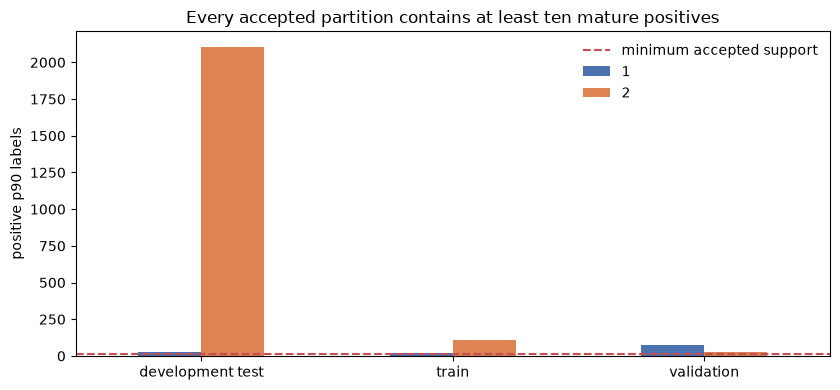

In [3]:
instruments = pd.read_parquet(DATA / '02_instrumentsdf_2.parquet')
availability = build_horizon_label_availability(
    instruments, target_column='is_pastdue90', horizon_days=90
)
support_rows = []
for fold_number, spec in enumerate(specs, start=1):
    fold = build_point_in_time_fold(instruments['invoice_date'], availability, spec)
    for partition, mask in [('train', fold.train_mask), ('validation', fold.validation_mask), ('development test', fold.test_mask)]:
        support_rows.append({
            'fold': fold_number,
            'partition': partition,
            'rows': int(mask.sum()),
            'positives': int(availability.labels[mask].sum()),
            'prevalence': availability.labels[mask].mean(),
        })
support = pd.DataFrame(support_rows)
display(support.style.format({'prevalence': '{:.2%}'}))

ax = support.pivot(index='partition', columns='fold', values='positives').plot.bar(
    figsize=(8.5, 4), color=['#4C72B0', '#DD8452']
)
ax.axhline(10, color='#C44E52', linestyle='--', label='minimum accepted support')
ax.set(title='Every accepted partition contains at least ten mature positives', ylabel='positive p90 labels', xlabel='')
ax.legend(frameon=False)
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

## 3. What is recomputed inside every fold?

The backtest is not a loop over a fixed feature matrix and fixed model. Strictly-prior raw histories are intrinsically safe to reuse because each row only queries older events. Everything learned from a population is fold-local: category vocabulary, missing-value medians, LightGBM tree count, neural epoch count, refit parameters, and the seen/cold-start company set.

The compared families are: causal LightGBM; a root-only nonlinear invoice model; and the temporal role GNN with four causal relation messages. Neural results use the same five frozen seeds.

## 4. Results change through time

The bars below show LightGBM's deterministic run and each neural family's five-seed mean. Error bars span the minimum and maximum seed—not a confidence interval. The dashed prevalence line is the no-ranking PR-AUC reference and changes sharply between periods.

,fold,train_end,validation_end,test_end,model,cohort,run_count,mean_pr_auc,sample_std,minimum,maximum,sample_count,positive_count,prevalence
0,1,2015-04-01,2016-04-01,2017-04-01,point_in_time_lightgbm,test_all,1,0.007,nan,0.007,0.007,6604,27,0.41%
1,1,2015-04-01,2016-04-01,2017-04-01,point_in_time_lightgbm,test_seen,1,0.009,nan,0.009,0.009,3245,12,0.37%
2,1,2015-04-01,2016-04-01,2017-04-01,point_in_time_lightgbm,test_cold_start,1,0.007,nan,0.007,0.007,3359,15,0.45%
3,1,2015-04-01,2016-04-01,2017-04-01,root_only_neural,test_all,5,0.008,0.005,0.004,0.018,6604,27,0.41%
4,1,2015-04-01,2016-04-01,2017-04-01,root_only_neural,test_seen,5,0.011,0.007,0.006,0.022,3245,12,0.37%
5,1,2015-04-01,2016-04-01,2017-04-01,root_only_neural,test_cold_start,5,0.010,0.007,0.004,0.022,3359,15,0.45%
6,1,2015-04-01,2016-04-01,2017-04-01,temporal_role_gnn,test_all,5,0.012,0.018,0.004,0.043,6604,27,0.41%
7,1,2015-04-01,2016-04-01,2017-04-01,temporal_role_gnn,test_seen,5,0.006,0.004,0.003,0.014,3245,12,0.37%
8,1,2015-04-01,2016-04-01,2017-04-01,temporal_role_gnn,test_cold_start,5,0.018,0.030,0.004,0.072,3359,15,0.45%
9,2,2016-04-01,2017-04-01,2018-04-01,point_in_time_lightgbm,test_all,1,0.120,nan,0.120,0.120,21556,2106,9.77%


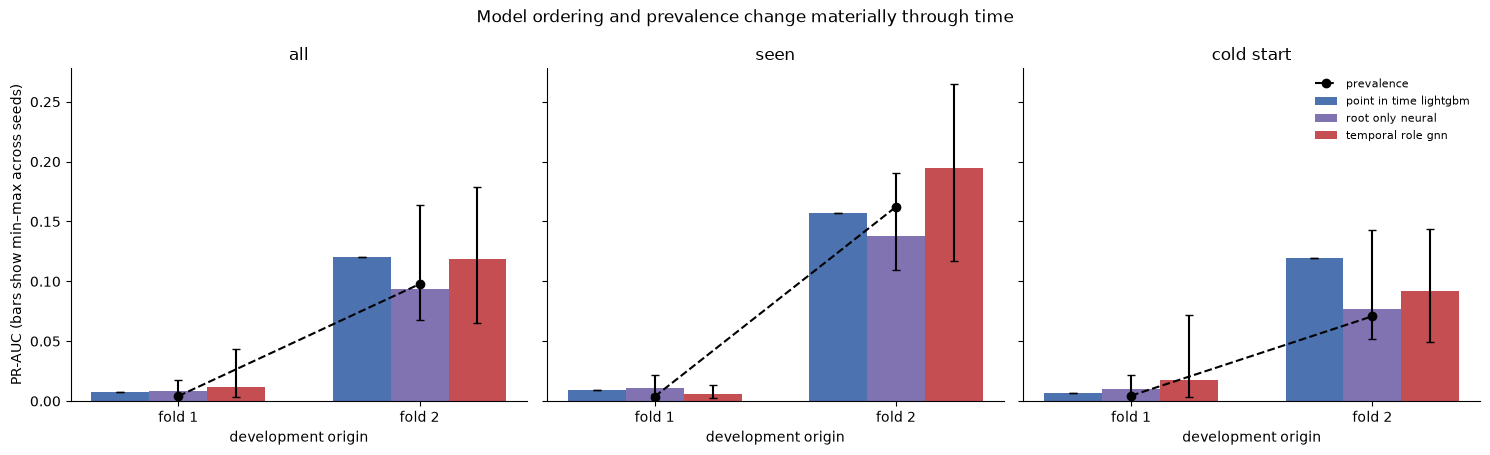

In [4]:
summary = pd.read_csv(ROOT / 'results' / 'temporal_backtest_p90_summary.csv')
display(summary.style.format({
    'mean_pr_auc': '{:.3f}', 'sample_std': '{:.3f}',
    'minimum': '{:.3f}', 'maximum': '{:.3f}', 'prevalence': '{:.2%}',
}))
plot_backtest_pr_auc(summary)
plt.show()

Fold 1 is an exceptionally low-prevalence period: only 27 positives among 6,604 mature test rows. Every absolute score is small and the temporal GNN is very seed-sensitive. Fold 2 is closer to the later risk regime. There, temporal GNN mean PR-AUC is 0.119 overall versus LightGBM's 0.120—effectively tied at this precision—and 0.194 versus 0.157 for seen companies, but 0.092 versus 0.119 for cold-start.

The robust conclusion is not “the GNN wins.” It is that model ordering, prevalence, and cold-start behaviour are non-stationary. Relation context appears most promising for companies with history, while neural initialization remains a material source of uncertainty.

## 5. Is a Transformer just attention added to a GNN?

That is a useful first intuition, but the more precise answer is: **graph attention replaces the GNN's fixed neighbour aggregator with a learned, query-dependent aggregator**. The graph still decides which events are candidate neighbours. The temporal rule removes candidates that were not available at prediction time. Attention then decides how much weight each remaining neighbour receives.

A standard Transformer allows every token to interact with every other token. That is wrong here: invoices from unrelated companies should not communicate, and future invoices must never communicate backward. A temporal graph Transformer keeps the Transformer attention calculation but restricts it using graph relations and event time.

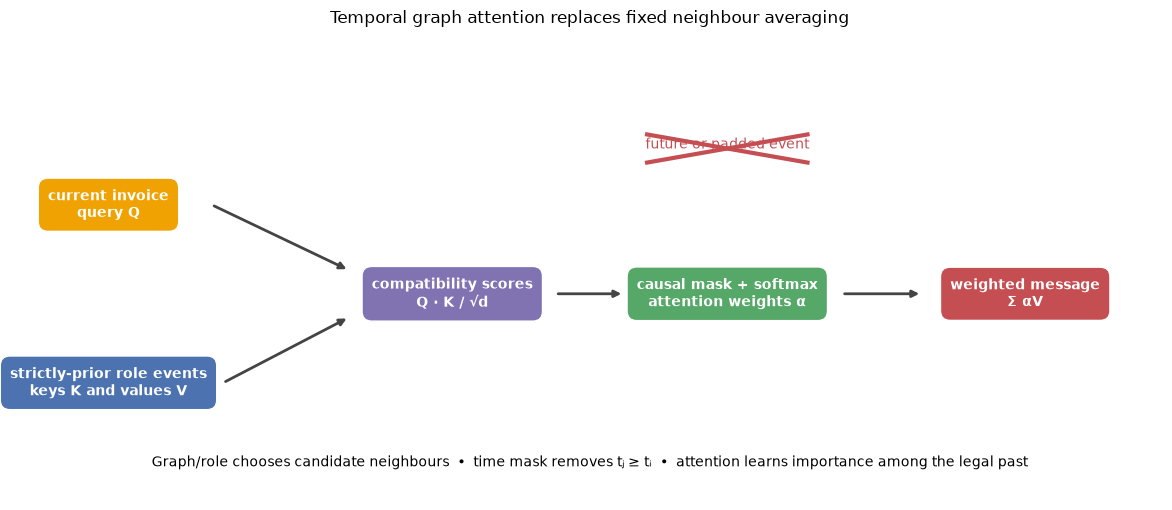

In [5]:
plot_temporal_attention_schematic()
plt.show()

### 5.1 Query, key, and value: three views of the same data

For current invoice $i$, the model creates a **query** $q_i=W_Qx_i$: what kind of historical evidence is relevant to this prediction? For each legal historical invoice $j$, it creates a **key** $k_{ij}$: what evidence does this event advertise? It also creates a **value** $v_{ij}$: what information should be passed if the event is selected? Keys and values may include the historical invoice features, its seller/buyer role, and its age relative to the current invoice.

The raw compatibility score is $s_{ij}=q_i^T k_{ij}/\sqrt{d}$. The dot product is high when query and key point in similar learned directions. Dividing by $\sqrt{d}$ prevents scores from growing simply because the hidden dimension $d$ is large, which would make softmax almost one-hot and gradients brittle.

Softmax converts legal scores into non-negative weights that sum to one: $\alpha_{ij}=\operatorname{softmax}_j(s_{ij})$. The message is $m_i=\sum_j \alpha_{ij}v_{ij}$. Unlike a mean, this aggregation is conditioned on the current invoice.

### 5.2 Where the graph and time enter

Three mechanisms prevent attention from becoming an unconstrained tabular Transformer:

1. **Graph neighbourhood:** candidates must share the current seller or buyer company. Unrelated invoices never enter the attention set.
2. **Relation encoding:** a learned vector identifies whether this is seller-as-seller, seller-as-buyer, buyer-as-seller, or buyer-as-buyer history. The same numeric event can mean something different in each role.
3. **Continuous time encoding:** event age $\Delta t=t_i-t_j$ is mapped to a vector, commonly using several sinusoidal frequencies or a small learned network. This lets attention learn recency patterns rather than imposing exactly one 180-day exponential curve.

A **causal mask** assigns score $-\infty$ before softmax whenever $t_j \ge t_i$. Its softmax weight becomes zero. The strict inequality also excludes simultaneous invoices, because their within-timestamp ordering is unknown. This mask is part of the model's data contract, not merely a training option.

### 5.3 Multi-head attention, bounded history, and padding

**Multi-head attention** repeats the query/key/value calculation several times with independent projections. One head might focus on very recent invoices, another on unusually large amounts, and another on cross-role hybrid behaviour. Head outputs are concatenated and projected back to the hidden size. More heads increase capacity, not guaranteed insight; their count belongs in validation-only selection.

Companies have very different degrees, so tensors need a fixed maximum of $K$ recent legal events per relation. This **neighbour cap** makes memory and compute predictable and prevents a 5,000-invoice hub from dominating a batch. Choosing the most recent $K$ is deterministic and causal; $K$ is still a hyperparameter. If fewer than $K$ events exist, empty positions are padding. A **padding mask** gives them zero attention, just like the causal mask. Mask polarity and all-empty rows require explicit unit tests because a single inversion can silently attend to fake or future events.

The attention message is combined with a **root/residual path** from the current invoice. This preserves current-invoice information and gives an exact fallback when no history exists. Layer normalization and a feed-forward block then refine each invoice independently. These are the same stabilization ideas used in ordinary Transformers, applied after graph-restricted aggregation.

### 5.4 What changes relative to the current model?

| Current temporal role GNN | Temporal graph Transformer candidate |
|---|---|
| One fixed 180-day decay | Learned continuous time encoding |
| One weighted mean per role | Attention over up to $K$ recent events per role |
| The same history summary for every current invoice | Query-dependent weights for each current invoice |
| Four relation-specific transforms | Relation encodings and/or relation-specific attention heads |
| Cost roughly linear in all history events | Cost roughly proportional to invoices × roles × $K$ × heads |
| Empty history represented by zero context | Padding mask plus explicit root-only fallback |

The value proposition is therefore **selective neighbour aggregation**, especially at hubs—not 'Transformers are newer.' The costs are higher variance, more parameters, more masking failure modes, and less immediate interpretability than a fixed decay.

### 5.5 What attention cannot fix

Attention can choose among available events; it cannot create evidence for a company with no prior events. A fully cold-start invoice therefore reduces to the root/current-invoice path. Better transferable company descriptors or stronger origination features are a separate modelling direction.

A useful first candidate is TGAT-style: current invoice query, strictly-prior role events as keys/values, continuous time encoding, and hard causal/padding masks. It should be tested on these development folds against LightGBM, root-only, and fixed-decay temporal GNN using the same five seeds and a comparable parameter budget.

## 6. Decision rule for the next experiment

Before implementing attention, first add a bounded recent-event representation and test its causal masks by changing future events and verifying earlier tensors remain identical. Then compare fixed-decay mean aggregation with temporal attention using the same folds, seeds, parameter-budget range, and stopping rule. Choose on development-fold aggregates; evaluate the sealed final holdout only after the architecture and hyperparameters are frozen.

## Takeaways

1. Temporal backtesting protects the final holdout from gradual test-driven tuning.
2. Window design must be checked after label maturity; calendar duration alone does not guarantee usable positives.
3. Performance and prevalence shift substantially through time, so one origin cannot establish a stable model ordering.
4. The temporal GNN is competitive with LightGBM for seen companies in the later development fold, but remains seed-sensitive and weaker on cold-start.
5. A temporal graph Transformer is worth testing after bounded causal event sequences exist. Its value proposition is learned neighbour relevance—not a magical fix for missing history.